# Interpolacija

## Uvod

Pri **interpolaciji** izhajamo iz tabele (različnih) vrednosti $x_i, y_i$:

| $\mathbf{x}$  | $\mathbf{y}$  |
|:-:|:-:|
| $x_0$  | $y_0$  |
| $x_1$  | $y_1$  |
| $\dots$   | $\dots$ |
| $x_{n-1}$| $y_{n-1}$|

določiti pa želimo vmesne vrednosti. Če želimo določiti vrednosti zunaj območja $x$ v tabeli, govorimo o **ekstrapolaciji**.

V okviru **interpolacije** (angl. *interpolation*) točke povežemo tako, da predpostavimo neko funkcijo in dodamo pogoj, da funkcija *mora* potekati skozi podane točke. 

Pri **aproksimaciji** (angl. *approximation* ali tudi *curve fitting*) pa predpostavimo funkcijo, ki se čimbolj (glede na izbrani kriterij) prilega podatkom. 

Poglejmo si primer:

| $\mathbf{x}$  | $\mathbf{y}$  |
|:-:|:-:|
| 1.0  | 0.54030231  |
| 2.5  | -0.80114362  |
| 4.0   | -0.65364362 |

Pri interpolaciji izhajamo iz tabele vrednosti. Da bomo pozneje lahko enostavno prikazali napako, smo zgornjo tabelo generirali s pomočjo izraza $y = \cos(x)$!

Pripravimo numerični zgled; najprej uvozimo pakete:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Nato pripravimo tabelo ter prikaz:

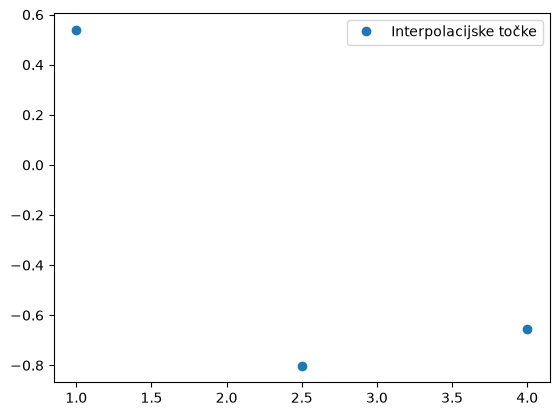

In [2]:
n = 3
x = np.linspace(1, 4, n)
f = np.cos # posplošimo interpolirano funkcijo (lahko spremenite v drugo funkcijo)
f_ime = f.__str__().split('\'')[1] # avtomatsko vzamemo ime funkcije
y = f(x)# + np.random.rand(len(x))*0.3
plt.plot(x, y, 'o', label='Interpolacijske točke');
plt.legend();

## Interpolacija s polinomom

Interpolacija s polinomom se zdi najbolj primerna, saj je enostavna! 

Polinom stopnje $n-1$:

$$
y = a_0\,x^{n-1} +a_1\,x^{n-2} +\cdots + a_{n-2}\,x + a_{n-1}.
$$

je definiran z $n$ konstantami $a_i$. Da določimo $n$ konstant, potrebujemo $n$ (različnih) enačb. Za vsak par $x_i, y_i$ lahko torej zapišemo:

$$
y_i = a_{0}\,x_i^{n-1} +a_{1}\,x_i^{n-2} +\cdots + a_{n-2}\,x_i + a_{n-1}.
$$

Ker imamo podanih $n$ parov, lahko določimo $n$ neznanih konstant $a_i$, ki definirajo polinom stopnje $n-1$. Sistem $n$ linearnih enačb lahko zapišemo:

$$
\begin{bmatrix}
x_{0}^{n-1}&x_{0}^{n-2}&\dots&x_{0}^0\\
x_{1}^{n-1}&x_{1}^{n-2}&\dots&x_{1}^0\\
&&\vdots&&\\
x_{n-1}^{n-1}&x_{n-1}^{n-2}&\dots&x_{n-1}^0\\
\end{bmatrix}
\begin{pmatrix}
a_{0}\\
a_{1}\\
\vdots\\
a_{n-1}
\end{pmatrix}=
\begin{pmatrix}
y_{0}\\
y_{1}\\
\vdots\\
y_{n-1}
\end{pmatrix}
$$

Sistem linearnih enačb zapišemo v obliki:

$$
\mathbf{M}\,\mathbf{a}=\mathbf{b}.
$$

Definirajmo matriko koeficientov $\mathbf{M}$:

In [3]:
M = np.asarray([[_**p for p in reversed(range(len(x)))] for _ in x])
M  

array([[ 1.  ,  1.  ,  1.  ],
       [ 6.25,  2.5 ,  1.  ],
       [16.  ,  4.  ,  1.  ]])

Izračunamo koeficiente $a_{0}, a_{1},\dots$:

In [4]:
resitev = np.linalg.solve(M, y)
resitev

array([ 0.33087687, -2.05236633,  2.26179176])

Pripravimo interpolacijski polinom kot Pythonovo funkcijo:

In [5]:
def y_function(x, resitev):
    A = np.asarray([[_**p for p in reversed(range(len(resitev)))] for _ in x])
    return A.dot(resitev)

Izris interpolacijskega polinoma pri bolj gosti mreži točk:

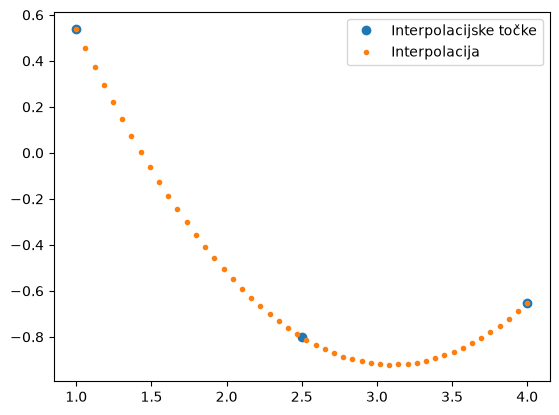

In [6]:
xint = np.linspace(np.min(x), np.max(x), 50)
yint = y_function(xint, resitev)
plt.plot(x, y, 'o', label='Interpolacijske točke')
plt.plot(xint, yint, '.',label='Interpolacija')
plt.legend();

Slabosti zgornjega postopka so:

 * število numeričnih operacij raste sorazmerno z $n^3$,
 * problem je lahko slabo pogojen (z večanjem stopnje polinoma slaba pogojenost naglo narašča):

In [7]:
np.linalg.cond(M)

np.float64(71.3022787031109)

*Navodilo*: vrnite se par vrstic nazaj in spremenite število interpolacijskih točk $n$ na višjo vrednost (npr. 10).

## Lagrangeva metoda

*Lagrangeva* metoda ne zahteva reševanja sistema enačb in je s stališča števila računskih operacij (narašča sorazmerno z $n^2$ ([vir](http://www.ams.org/journals/mcom/1970-24-109/S0025-5718-1970-0258240-X/S0025-5718-1970-0258240-X.pdf))) boljša od predhodno predstavljene polinomske interpolacije (število operacij narašča sorazmerno z $n^3$), kjer smo reševali sistem linearnih enačb. Rešitev pa je seveda popolnoma enaka!

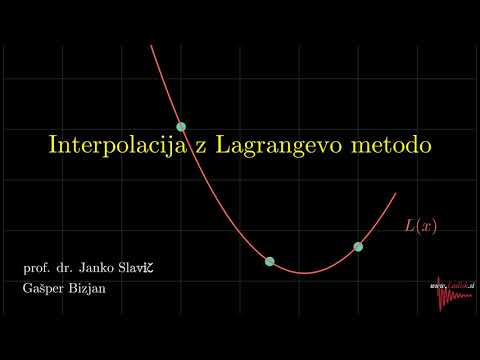

In [8]:
from IPython.display import YouTubeVideo
YouTubeVideo('c_TbU8XBHsw', width=800, height=300)

Lagrangev interpolacijski polinom stopnje $n-1$ je definiran kot:

$$
P_{n-1}(x)=\sum_{i=0}^{n-1}y_i\,l_i(x),
$$

kjer je $l_i$ Lagrangev polinom:

$$
l_i(x)=\prod_{j=0, j\ne i}^{n-1} \frac{x-x_j}{x_i-x_j}.
$$

Poglejmo si interpolacijo za zgoraj prikazane $x$ in $y$ podatke.

Definirajmo najprej Lagrangeve polinome $l_i(x)=\prod_{j=0, j\ne i}^{n-1} \frac{x-x_j}{x_i-x_j}$:

In [9]:
def lagrange(x, x_int, i):
    """ Vrne vrednosti i-tega Lagrangevega polinoma
    
    x: neodvisna spremenljivka (skalar ali numerično polje)
    x_int: seznam interpolacijskih točk
    i: indeks polinoma
    """
    Lx = 1.0
    for j in range(len(x_int)):
        if j != i:
            Lx *= (x-x_int[j]) / (x_int[i]-x_int[j])
    return Lx

In [10]:
def slika(i=0):
    xint = np.linspace(np.min(x), np.max(x), 30)
    plt.plot(x, y, 'o', label='Interpolacijske točke')
    plt.axhline(0, color='k', linewidth=0.3);
    plt.plot(xint, lagrange(xint, x_int=x, i=i), '.',label=f'Lagrangev polinom i={i}');
    for _ in x:
        plt.axvline(_, color='r', linewidth=0.5);
    plt.legend()
    plt.show()

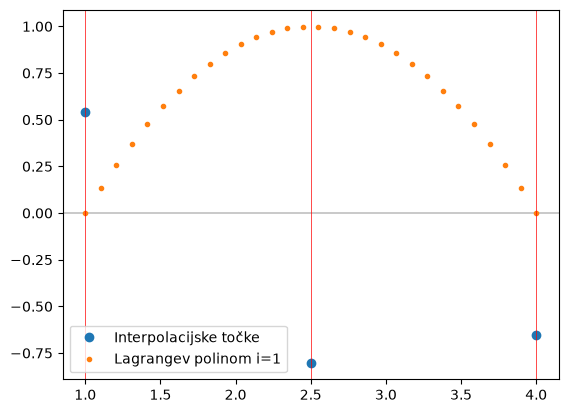

In [11]:
slika(i=1)

Opazimo, da ima $i$-ti Lagrangev polinom v $x_i$ vrednost 1, v ostalih podanih točkah pa nič!

Če torej Lagrangev polinom za $i=0$ pomnožimo z $y_0$, bomo pri $x=x_0$ dobili pravo vrednost, v ostalih interpolacijskih točkah pa nič; implementirajmo torej Lagrangev interpolacijski polinom:

$$
P_{n-1}(x)=\sum_{i=0}^{n-1}y_i\,l_i(x),
$$


In [12]:
def lagrange_interpolacija(x, x_int, y_int):
    """ Vrne vrednosti Lagrangeve interpolacije
    
    x: neodvisna spremenljivka (skalar ali numerično polje)
    x_int: abscisa interpolacijskih točk
    y_int: ordinata interpolacijskih točk
    """
    y = 0.
    for i in range(len(x_int)):
        Lx = 1.0
        for j in range(len(x_int)):
            if j != i:
                Lx *= (x-x_int[j]) / (x_int[i]-x_int[j])
        y += y_int[i] * Lx
    return y

Pripravimo sliko:

In [13]:
def slika(i=0):
    xint = np.linspace(np.min(x), np.max(x), 30)
    plt.plot(x, y, 'o', label='Interpolacijske točke')
    plt.plot(xint, lagrange(xint, x_int=x, i=i), '.',label=f'Lagrangev polinom i={i}');
    plt.plot(xint, lagrange_interpolacija(xint, x_int=x, y_int=y), '.',label=f'Lagrangev int polinom');
    plt.axhline(0, color='k', linewidth=0.3);
    for _ in x:
        plt.axvline(_, color='r', linewidth=0.5);
    plt.legend()
    plt.show()

Iz `ipywidgets` uvozimo ``interact``, ki je močno orodje za avtomatsko generiranje (preprostega) uporabniškega vmesnika znotraj `jupyter` okolja. Tukaj bomo uporabili relativno preprosto interakcijo s sliko; za pregled vseh zmožnosti pa radovednega bralca naslavljamo na [dokumentacijo](http://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html).

Uvoz funkcije ``interact``

In [14]:
from ipywidgets import interact

In [15]:
interact(slika);

interactive(children=(IntSlider(value=0, description='i', max=1), Output()), _dom_classes=('widget-interact',)…

Iz slike vidimo, da ima Lagrangev polinom $i$ samo pri $x_i$ vrednost 1 v ostalih točkah $\ne i$ pa ima vrednosti nič; ko Lagrangev polinom $l_i(x)$ pomnožimo z $y_i$ zadostimo $i$-ti točki iz tabele. Posledično Lagrangeva interpolacija z vsoto Lagrangevih polinomov interpolira tabelo.

Polinomska interpolacija pri velikem številu točk je lahko slabo pogojena naloga in zato jo odsvetujemo. 

### Ocena napake

Če je $f(x)$ funkcija, ki jo interpoliramo in je $P_{n-1}(x)$ interpolacijski polinom stopnje $n-1$, potem se lahko pokaže (glejte npr.: Burden, Faires, Burden: Numerical Analysis), da je napaka interpolacije s polinomom:

$$
e=f(x)-P_{n-1}(x)=\frac{f^{(n)}(\xi)}{n!}\,(x-x_0)\,(x-x_1)\,\cdots\,(x-x_{n-1}),
$$

kjer je $f^{(n)}$ odvod funkcije, $n-1$ stopnja interpolacijskega polinoma in $\xi$ vrednost na interpoliranem intervalu $[x_0, x_{n-1}]$.

### Zgled

Tukaj si bomo ogledali interpolacijo točk:

In [16]:
x = np.array([0.        ,  0.52359878,  1.04719755,  1.57079633])
y = np.array([ 0.       ,  0.5      ,  0.8660254,  1.       ])

Točke prikažimo:

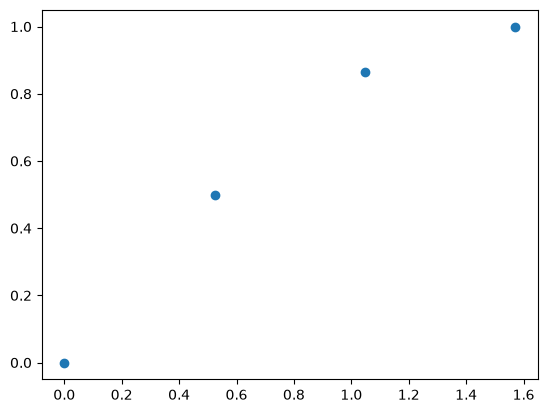

In [17]:
plt.plot(x, y, 'o');

Linearna interpolacija za vrednost pri `x=1.57079633/2`:

In [18]:
y_linearna = lagrange_interpolacija(x=x[-1]/2, x_int=x[1:3], y_int=y[1:3])
y_linearna

np.float64(0.6830127)

Kvadratna:

In [19]:
y_kvadratna = lagrange_interpolacija(x=x[-1]/2, x_int=x[0:3], y_int=y[0:3])
y_kvadratna

np.float64(0.6997595236464176)

Kubična

In [20]:
y_kubična = lagrange_interpolacija(x=x[-1]/2, x_int=x, y_int=y)
y_kubična

np.float64(0.705889286844634)

### Zgled ocene napake

Pri interpolaciji ponavadi funkcije $f(x)$ ne poznamo in napako ocenimo s pomočjo formule:

$$
e=\frac{f^{(n)}(\xi)}{n!}\,(x-x_0)\,(x-x_1)\,\cdots\,(x-x_{n-1}).
$$

Pri tem vrednost $\xi$  ni znana; ker je v primeru linearne interpolacije ($n=2$) drugi odvod sinusne funkcije ($f^{(n)}$) med -1 in +1, velja:

$$
|e|\le\left|\frac{-1}{2!}\,(\pi/4-\pi/6)\,(\pi/4-\pi/3)\right|=\frac{1}{2}\,\frac{\pi}{12}\,\frac{\pi}{12}=\frac{\pi^2}{288}=0,034
$$

Poleg **Lagrangeve metode** bi si tukaj lahko pogledali še **Newtonovo metodo** interpolacije.

### Interpolacija z uporabo `scipy`

Poglejmo si interpolacijo v okviru modula `scipy.interpolate` ([dokumentacija](https://docs.scipy.org/doc/scipy/reference/interpolate.html)).

Uporabili bomo funkcijo za interpoliranje tabele z zlepki, `scipy.interpolate.interp1d` ([dokumentacija](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d)):

```python
interp1d(x, y, kind='linear', axis=-1, copy=True, bounds_error=None, fill_value=nan, assume_sorted=False)
```

Podati moramo vsaj dva parametra: seznama interpolacijskih točk `x` in `y`. Privzeti parameter `kind='linear'` pomeni, da interpoliramo z odsekoma linearno funkcijo. `interp1d` vrne funkcijo `f`, ki jo kličemo (npr. `y = f(x)`) za izračun interpolirane vrednosti. 

Parameter `kind` je lahko npr. tudi: `'zero'`, `'slinear'`, `'quadratic'` in `'cubic'`; takrat se uporabi interpolacijski zlepek (ang. *spline*) reda 0, 1, 2 oz. 3. Zlepke si bomo pogledali v naslednjem poglavju.

**Opomba**: `interp1d` je v SciPy označena kot *legacy* (starejši vmesnik, ki se ne razvija več, a še deluje). Za nove programe SciPy priporoča `numpy.interp` (odsekoma linearna interpolacija), `scipy.interpolate.CubicSpline` ([dokumentacija](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html)) in `scipy.interpolate.make_interp_spline` ([dokumentacija](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html)); vse vrnejo objekt, ki ga kličemo enako kot `f` spodaj.

In [21]:
from scipy.interpolate import interp1d

Definirajmo tabelo podatkov:

In [22]:
x = np.array([ 1.        ,  2.14285714,  3.28571429,  4.42857143,  5.57142857,
        6.71428571,  7.85714286,  9.        ])

y = np.array([ 0.84147098,  0.84078711, -0.14362322, -0.95999344, -0.65316501,
        0.41787078,  0.999995  ,  0.41211849])

In [23]:
len(x)

8

In [24]:
from scipy.interpolate import interp1d

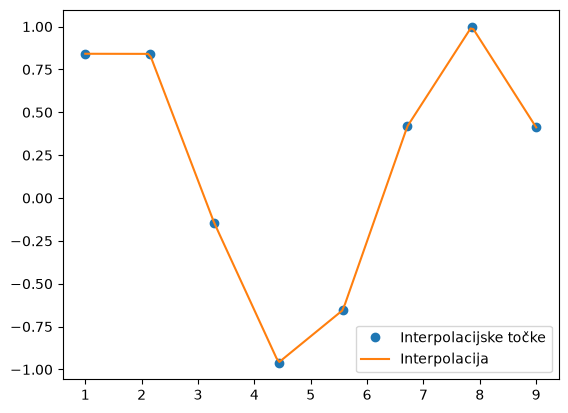

In [25]:
f = interp1d(x, y, kind='linear')
x_g = np.linspace(x[0], x[-1], 20*len(x)-1)
plt.plot(x, y, 'o', label='Interpolacijske točke')
plt.plot(x_g, f(x_g), '-', label='Interpolacija')
plt.legend();

## Kubični zlepki

Preden gremo v teorijo zlepkov, si poglejmo rezultat, ki ga dobimo s klicanjem funkcije `interp1d` s parametrom `kind='cubic'` (rezultat je kubični zlepek).

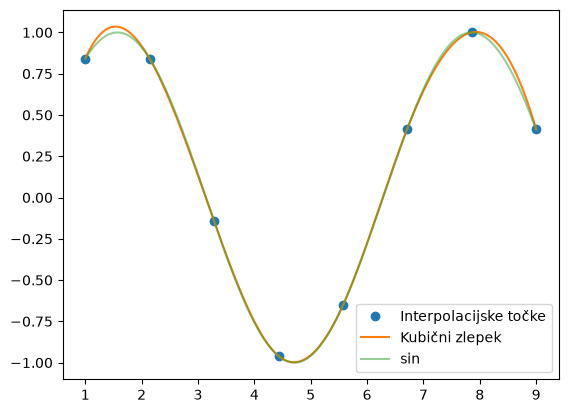

In [26]:
f = interp1d(x, y, kind='cubic')
plt.plot(x, y, 'o', label='Interpolacijske točke')
plt.plot(x_g, f(x_g), '-', label='Kubični zlepek')
plt.plot(x_g, np.sin(x_g), label='sin', alpha=0.5)
plt.legend();

Kubični zlepki so pogost način interpolacije. 

Zahtevamo, da je: $x_0<x_1< \cdots <x_n$.

Od točke $x_i$ do $x_{i+1}$ naj bo zlepek 
polinom:

$$
f_{i,i+1}(x)= a_{i,3}\,x^3+a_{i,2}\,x^2+a_{i,1}\,x+a_{i,0},
$$

pri čemer so neznane vrednosti konstant $a_{i,j}$. 

Če imamo na primer $n+1$ točk, potem je treba določiti $n$ polinomov. 

Celotni zlepek čez $n+1$ točk je definiran z:

$$
f(x) = \left\{
\begin{array}{rcl}
f_{0,1}(x); && x\in[x_0, x_1)\\
f_{1,2}(x); && x\in[x_1, x_2)\\
&\vdots&\\
f_{n-1,n}(x); && x\in[x_{n-1}, x_n]
\end{array}
\right.
$$

Vsak polinom $f_{i,i+1}$ je definiran s 4 konstantami $a_{i,j}$; skupaj torej moramo izračunati $4n$ konstant $a_{i,j}$.


**Kako določimo konstante $a_{i,j}$?**

Za določitev $4n$ neznank potrebujemo $4n$ enačb. Poglejmo si, kako jih dobimo:

* $n$ enačb dobimo iz interpolacijskega pogoja: $y_i=f_{i,i+1}(x_i),\quad i=0,1,2,\dots,n-1$
* 1 enačbo iz zadnje točke: $y_n=f_{n-1,n}(x_n)$
* $3(n-1)$ enačb dobimo iz pogoja $C^2$ zveznosti: 

$$
\lim_{x\rightarrow x_i^-}f(x)=\lim_{x\rightarrow x_i^+}f(x),
$$

$$
\lim_{x\rightarrow x_i^-}f'(x)=\lim_{x\rightarrow x_i^+}f'(x)
$$

in

$$
\lim_{x\rightarrow x_i^-}f''(x)=\lim_{x\rightarrow x_i^+}f''(x).
$$

Skupaj imamo definiranih $4n-2$ enačbi, manjkata torej še dve! 

Različni tipi zlepkov se ločijo po tem, kako ti dve enačbi določimo. V nadaljevanju si bomo pogledali *naravne kubične zlepke*.

### Naravni kubični zlepki

*Naravni kubični zlepki* temeljijo na ideji Eulerjevega nosilca:

$$
E\,I\,\frac{\textrm{d}^4y}{\textrm{d}x^4}=q(x),
$$

kjer je $E$ modul elastičnosti, $I$ drugi moment preseka in $q(x)$ zunanja porazdeljena sila. Ker zunanje porazdeljene sile ni ($q(x)=0$), velja:

$$
E\,I\,\frac{\textrm{d}^4y}{\textrm{d}x^4}=0.
$$

Sledi, da lahko v vsaki točki tanek nosilec popišemo s polinomom tretje stopnje. 

$C^2$ zveznost je zagotovljena v kolikor so vmesne podpore nosilca členki (moment zato nima nezvezne spremembe).

Manjkajoči 2 neznanki pri naravnih kubičnih zlepkih določimo iz pogoja, da je moment na koncih enak nič (členkasto vpetje):

$$
f''(x_{0})=0\qquad\textrm{in}\qquad f''(x_{n})=0
$$

Izpeljava je natančneje prikazana v knjigi Kiusalaas J: Numerical Methods in Engineering with Python 3, 2013, stran 120 (glejte tudi J. Petrišič: Interpolacija, Fakulteta za strojništvo, 1999); podrobna izpeljava presega namen te knjige. 

Tukaj si bomo pogledali samo končni rezultat, ki ga lahko izpeljemo ob zgornjih pogojih. V primeru ekvidistantne delitve $h=x_{i+1}-x_i$ tako izpeljemo sistem enačb ($i=1,\dots,n-1$):

$$
k_{i-1} + 4 k_{i} + k_{i+1}  =  \frac{6}{h^2} \left(y_{i-1} -2 y_{i} +y_{i+1} \right).
$$

kjer je neznanka $k_i$ drugi odvod odsekovne funkcije $k_i = f''_{i,i+1}(x_i)$.

Rešljiv sistem enačb dobimo, če dodamo še robna pogoja za naravne kubične zlepke:

$$
k_0=k_n=0.
$$

Ko določimo neznake $k_i$, jih uporabimo v odsekoma definirani funkciji:

$$
f_{i,i+1}(x)=\frac{k_{i+1}}{6}\left(\frac{(x-x_{i})^3}{h}-(x-x_{i})\,h\right)
-\frac{k_{i}}{6}\left(\frac{(x-x_{i+1})^3}{h}-(x-x_{i+1})\,h\right)
+\frac{y_{i+1}\,(x-x_{i})-y_i\,(x-x_{i+1})}{h}.
$$

### Numerična implementacija

Najprej pripravimo funkcijo, katera za podane interpolacijske točke reši sistem linearnih enačb in vrne koeficiente $k_i$:

In [27]:
def kubicni_zlepki_koeficient(x, y):
    """ Vrne koeficiente kubičnih zlepkov `k`, matriko koeficientov `A` in konstant.
    
    x in y predstavljata seznam znanih vrednosti; x mora biti ekvidistanten.
    """
    n = len(x)
    A = np.zeros((n, n)) # pripravimo matriko koeficientov
    h = x[1]-x[0] # korak h
    for i in range(n):
        if i==0 or i==n-1:
            A[i,i] = 1. # k_0 in k_n sta nič zato tukaj damo 1
                       # pri vektorju konstant pa bomo dali 0, k_0 in k_n bosta torej 0
        else:
            A[i, i-1:i+2] = np.asarray([1., 4., 1.])
    b = np.zeros(n)
    b[1:-1] = (6/h**2)*(y[:-2] - 2*y[1:-1] + y[2:]) # desna stran zgornje enačbe
    k = np.linalg.solve(A,b)
    return k, A, b

Opomba: pri zgornjem linearnem problemu, lahko izračun zelo pohitrimo, če upoštevamo tridiagonalnost matrike koeficientov! (Glejte [odgovor na stackoverflow.com](https://stackoverflow.com/questions/23120164/optimize-ax-b-solution-for-a-tridiagonal-coefficient-matrix)).

Poglejmo si primer izračuna koeficientov:

In [28]:
x = np.asarray([1, 2, 3, 4, 5])
y = np.asarray([0, 1, 0, 1, 0])

k, A, b = kubicni_zlepki_koeficient(x, y)
print('Matrika koeficientov A lin. sistema:\n', A)
print('Vektor konstant b lin. sistema:     ', b)
print('Koeficienti k so:', k)

Matrika koeficientov A lin. sistema:
 [[1. 0. 0. 0. 0.]
 [1. 4. 1. 0. 0.]
 [0. 1. 4. 1. 0.]
 [0. 0. 1. 4. 1.]
 [0. 0. 0. 0. 1.]]
Vektor konstant b lin. sistema:      [  0. -12.  12. -12.   0.]
Koeficienti k so: [ 0.         -4.28571429  5.14285714 -4.28571429  0.        ]


Nato potrebujemo še kubični polinom v določenem intervalu; implementirajmo izraz:

$$
f_{i,i+1}(x)=\frac{k_{i+1}}{6}\left(\frac{(x-x_{i})^3}{h}-(x-x_{i})\,h\right)
-\frac{k_{i}}{6}\left(\frac{(x-x_{i+1})^3}{h}-(x-x_{i+1})\,h\right)
+\frac{y_{i+1}\,(x-x_{i})-y_i\,(x-x_{i+1})}{h}
$$

In [29]:
def kubicni_zlepki(k, x, y, x_najdi):
    """ Vrne kubicni zlepek pri delitvi `xint`.
    
    :param k: koeficienti kubičnih zlepkov
    :param x in y: znane vrednosti, x mora biti ekvidistanten
    :param x_najdi: vrednosti kjer želimo izračunati kubični zlepek
    """  
    h = x[1] - x[0]
    i = int((x_najdi-x[0])//h)
    if i >= len(k)-1:
        i = len(k)-2
    out = ((x_najdi - x[i])**3/h - (x_najdi - x[i])*h)*k[i+1]/6.0 \
        - ((x_najdi - x[i+1])**3/h - (x_najdi - x[i+1])*h)*k[i]/6.0 \
        + (y[i+1]*(x_najdi - x[i]) \
        - y[i]*(x_najdi - x[i+1]))/h
    return out

Izračunamo interpolirane vrednosti:

In [30]:
xint = np.linspace(np.min(x), np.max(x), 50)
yint = np.asarray([kubicni_zlepki(k, x, y, _) for _ in xint])

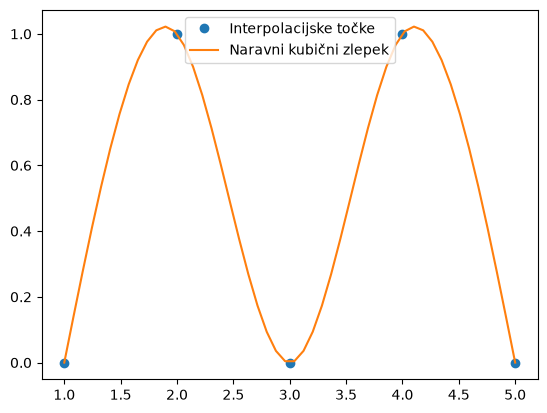

In [31]:
plt.plot(x, y, 'o', label='Interpolacijske točke')
plt.plot(xint, yint, label='Naravni kubični zlepek')
plt.legend();

# Dodatno

* 2D interpolacija: https://www.youtube.com/watch?v=_cJLVhdj0j4
* Strojno prevajanje: https://pypi.org/project/goslate

## Nekaj komentarjev modula ``scipy.interpolate``

SciPy ima implementiranih večje število različnih interpolacij ([glejte dokumentacijo](https://docs.scipy.org/doc/scipy/reference/interpolate.html)). S stališča uporabe se bomo tukaj dotaknili  objektne implementacije `scipy.interpolate.InterpolatedUnivariateSpline` ([dokumentacija](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.InterpolatedUnivariateSpline.html)) (starejši pristop temelji na proceduralnem programiranju, glejte  [dokumentacijo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splrep.html) `scipy.interpolate.splrep`):

```python
InterpolatedUnivariateSpline(x, y, w=None, bbox=[None, None], k=3, ext=0, check_finite=False)
```

Pri inicializaciji objekta `InterpolatedUnivariateSpline` moramo posredovati interpolacijske točke `x` in `y`. Argument `k` s privzeto vrednostjo `k=3` definira red interpolacijskega zlepka (`1<=k<=5`). Pomemben opcijski parameter je tudi `w`, ki definira uteži posameznim interpolacijskim točkam (uporabimo ga, če želimo določenim področjem dati večji poudarek).

**Opomba**: `InterpolatedUnivariateSpline` (in sorodni `UnivariateSpline`) sta od SciPy 1.15 označena kot *legacy*; sodobnejša ekvivalenta sta `make_interp_spline` (interpolacija) in `make_smoothing_spline` oz. `make_splrep` (aproksimacija, glejte naslednje predavanje). Objektni vmesnik spodaj še vedno deluje in je zaradi preglednosti primeren za učenje.

In [32]:
from scipy.interpolate import InterpolatedUnivariateSpline

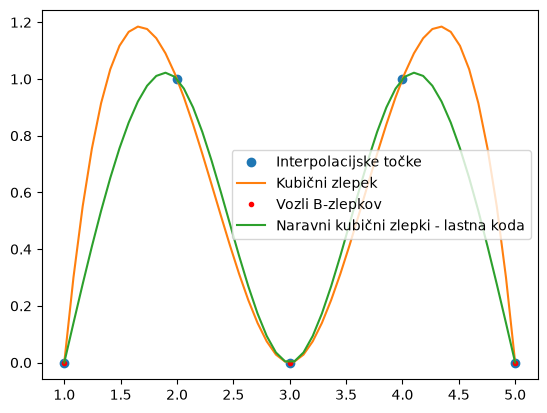

In [33]:
spl = InterpolatedUnivariateSpline(x, y, k=3) # poglejte opcije!
plt.plot(x, y, 'o', label='Interpolacijske točke')
plt.plot(xint, spl(xint), label='Kubični zlepek');
plt.plot(spl.get_knots(), spl(spl.get_knots()), 'r.', label='Vozli B-zlepkov')
plt.plot(xint, yint, label='Naravni kubični zlepki - lastna koda');
plt.legend();

Ker gre za B-zlepke, je rezultat drugačen kot tisti, ki smo ga izpeljali z naravnimi kubičnimi zlepki. V nasprotju z naravnimi kubičnimi zlepki, ki imajo vozle (angl. *knots*) v interpolacijskih točkah, se vozli B-zlepkov prilagodijo podatkom. V konkretnem primeru so vozli v točkah:

In [34]:
spl.get_knots()

array([1., 3., 5.])

### Odvajanje, integriranje ... zlepkov

Zlepke lahko odvajamo in integriramo, saj so polinomi. Objekt ``InterpolatedUnivariateSpline`` je tako že pripravljen za odvajanje, integriranje, iskanje korenov (ničel), vozlov ... (glejte [dokumentacijo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.InterpolatedUnivariateSpline.html)).

Za prvi odvod zlepka v objektu `spl` na primer uporabimo metodo ``spl.derivative(1)``, ki vrne nov objekt zlepka (njen red je sedaj za 1 nižji):

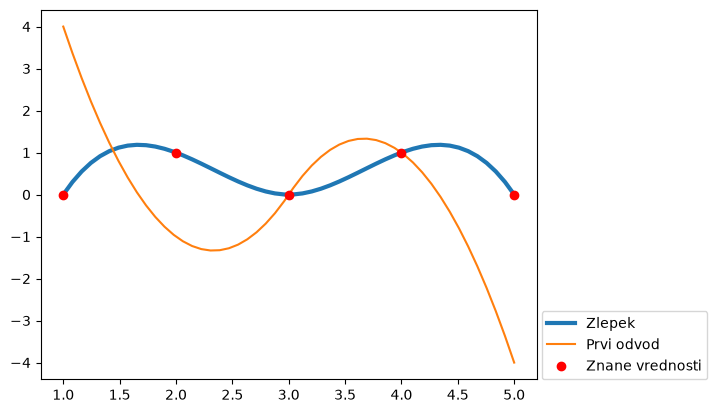

In [35]:
spl1 = spl.derivative(1)
#spl2 = spl.derivative(2)
#spl3 = spl.derivative(3)
plt.plot(xint, spl(xint), lw=3, label='Zlepek')
plt.plot(xint, spl1(xint), label='Prvi odvod')
#plt.plot(xint, spl2(xint), label='Drugi odvod')
#plt.plot(xint, spl3(xint), label='Tretji odvod')
plt.plot(x, y, 'ro', label='Znane vrednosti')
#plt.plot(spl.get_knots(), spl(spl.get_knots()), 'k.', label='Vozli B-zlepka')
plt.legend(loc=(1.01, 0));

---

# Vprašanja za vaje

---

## Lagrangeva metoda

In [36]:
def lagrange_i(x, x_int, i):
    """ Vrne vrednosti i-tega Lagrangevega polinoma
    
    x: seznam vrednosti x točk, ki jih interpoliramo
    x_int: neodvisna spremenljivka (točke, pri katerih iščemo vrednosti)
    i: indeks Lagrangevega polinoma
    """
    Li = 1.0
    for j in range(len(x)):
        
        if j != i:
            Li *= (x_int-x[j]) / (x[i]-x[j])
    return Li

In [37]:
# Primer
x = np.linspace(0,1,4)
y = np.random.rand(len(x))
x_int = np.linspace(np.min(x), np.max(x), 50)

**Vprašanje 1:** Pripravite funkcijo ``lagrange_interpolacija``, ki kot argumente sprejme numerični polji ``x`` in ``y`` koordinat znanih točk ter numerično polje ``x_int`` koordinat, pri katerih nas zanimajo interpolirane vrednosti. 

Za vsako izmed znanih točk $x_i$ naj s pomočjo funkcije ``lagrange_i`` izračuna vrednosti polinoma $l_i$ v točkah ``x_int`` ter na koncu izračuna in vrne vrednosti ``y_int`` $= P_n($ ``x_int`` $)$, tako, da izračuna vsoto:

$$P_n(x_{\text{int}}) = \sum_{i=0}^{n}y_il_i(x_{\text{int}})$$


**Vprašanje 2:** Pripravite nabor petih točk ``x``, enakomerno razporejenih na intervalu $x\in[0,2 \pi]$, ter pripadajočih vrednosti ``y``, definiranih kot:

$$y = \sin(x)$$

Za 100 točk ``x_int`` na istem intervalu izračunajte interpolacijsko krivuljo (uporabite ustrezno funkcijo iz `scipy`). 

Na istem grafu prikažite točke ``(x,y)``, interpolacijsko krivuljo ter prave vrednosti $y$ pri točkah ``x_int``.

Kako bi izračunali napako pri interpolaciji v odvisnosti od vrednosti ``x_int``? (Prave vrednosti $y$ poznamo!)

----------

## Kubični zlepki

In [41]:
# Primer
x = np.linspace(0,1,10)
y = np.random.rand(len(x)) - 0.5
x_int = np.linspace(x[0], x[-1], 100)

Primerjava ``InterpolatedUnivariateSpline`` in ``interp1d``:

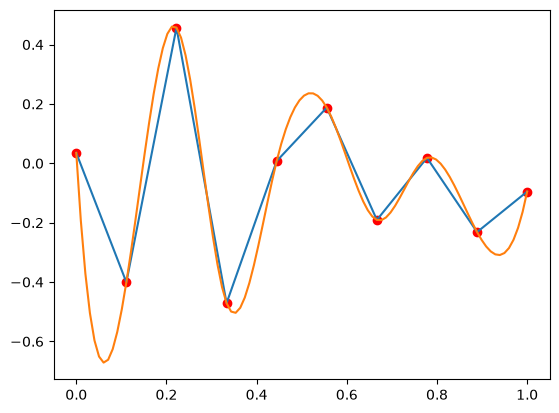

In [42]:
plt.plot(x, y, 'ro')
plt.plot(x_int, interp1d(x, y)(x_int))
plt.plot(x_int, InterpolatedUnivariateSpline(x, y)(x_int))

**Vprašanje 3:** Z uporabo poljubne ``scipy`` funkcije pripravite grafični prikaz interpolacije pripravljenih točk ``(x, y)`` z linearnimi, kvadratnimi in kubičnimi zlepki.

**Vprašanje 4:** Za točke ``x, y`` primerjajte interpolacijsko krivuljo kubičnih zlepkov ``scipy.interpolate.InterpolatedUnivariateSpline`` z rezultatom Lagrangeve interpolacije.

**Vprašanje 5:** Za krivuljo kubičnih interpolacijskih zlepkov, dobljenih pri prejšnji nalogi z uporabo ``scipy`` funkcije poiščite ničle. 

Rezultate grafično prikažite.

**Vprašanje 6:** Grafično prikažite krivuljo zlepkov iz prejšnje naloge in njene odvode. 

**Vprašanje 7:** Podane točke ``(t, a)`` predstavljajo izmerjen potek pospeškov avtomobila v smeri vožnje. Z uporabo ``scipy.interpolate.InterpolatedUnivariateSpline`` določite interpolacijsko krivuljo z zlepki 2. reda pri časih ``t_int``. 

Uporabite obstoječo funkcijo in določite ter grafično prikažite tudi krivulji hitrosti in opravljene poti (namig: ``help(InterpolatedUnivariateSpline)``).

In [47]:
# Podatki
t = np.array([0, 1, 2, 3, 4, 5])
a = np.array([5, 3, 0, 0, -4, -3])
t_int = np.linspace(t[0], t[-1], 50)